In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial, eval_hermite
from qutip import (basis, squeeze, tensor, sigmax, sigmay, sigmaz,
                   identity, momentum, mesolve, destroy, Qobj, expect)


In [7]:

# --- 1. CONFIGURATION (TUNED FOR ACCURACY) ---
omega = 3
beta = 0.8
r_target = 8 # MZ: used to be 8
r_prime = 6

N_dim = 70          # Keep high dimension

total_time = 5.0
n_steps = 500 # MZ: used to be 100
T_step = total_time / n_steps

USE_MOMENTUM_BUS = False
MOMENTUM_SCALE = 1.0  # adjust if using momentum bus
USE_STRANG = True
PLOT_ABS = True
PLOT_EXACT = True
PLOT_OSC = True
PLOT_P = False

# Derived Gamma
gamma = np.exp(-2 * r_prime) - np.exp(-2 * r_target)


In [8]:
from numpy.polynomial.hermite import hermgauss

# --- 2. STATE PREPARATION (Optimized: Gauss-Hermite Quadrature) ---
print(f"1. Preparing States (N={N_dim}, r={r_target}) using Quadrature...")

# 1. Determine integration weight parameters
# We are integrating f(p) * exp(-p^2 / (2w^2)).
# Gauss-Hermite integrates g(x) * exp(-x^2). We need to change variables.
# Let x = p / (sqrt(2) * width_param)  =>  p = x * sqrt(2) * w
width_param = np.exp(r_prime)
scale_factor = np.sqrt(2) * width_param

# 2. Get Quadrature Points and Weights (No linear grid needed!)
# deg=200 is sufficient for N=80. It replaces 80,000 grid points.
x_roots, weights = hermgauss(200)

# Map roots to physical momentum p
p_points = x_roots * scale_factor

# 3. Evaluate Target Function at these specific points ONLY
C_val = 2 * np.pi * np.exp(-2 * beta)
term_exp = np.exp((1 + 1j * p_points)**beta)
denom_func = C_val * term_exp * (1 - 1j * p_points)

# Note: We remove one Gaussian factor from the target because the
# Quadrature weight includes exp(-x^2) implicitly.
# The basis state has exp(-p^2/2w^2). This cancels the weight function exp(-x^2).
# We only need to handle the "excess" Gaussian decay from the target.
target_part = np.exp(-gamma * p_points**2) / denom_func

cn_list = []
sqrt_pi = np.sqrt(np.pi)
basis_prefactor = 1.0 / np.sqrt(sqrt_pi * width_param)

for n in range(N_dim):
    # Fock Norm
    fock_norm = 1.0 / np.sqrt((2**n) * factorial(n))

    # Evaluate Hermite at the quadrature points
    # H_n(p/w) = H_n(x * sqrt(2))
    H_val = eval_hermite(n, p_points / width_param)

    # The Integral:
    # Int [ Target(p) * Basis(p) dp ]
    # Via Change of variables dp = scale_factor * dx
    # The weights w_i account for exp(-x^2).

    integrand = target_part * (basis_prefactor * fock_norm * H_val)

    # Sum weighted points * Jacobian (scale_factor)
    # We must explicitly multiply by exp(x^2) because we are integrating
    # functions that might not perfectly match the weight form,
    # but simpler logic:
    # Integral approx = sum( w_i * f(x_i) ) where integral is over e^-x^2 f(x).
    # Our Basis contains e^-x^2. The Weight contains e^-x^2.
    # We evaluate the "non-gaussian" part of the overlap.

    val = np.sum(weights * integrand) * scale_factor
    cn_list.append(val)

cn_array = np.array(cn_list)
# Normalize explicitly to correct any quadrature drift
psi_seed = sum([cn_array[n] * basis(N_dim, n) for n in range(N_dim)]).unit()

# Apply Squeezing (Basis Transform)
S_op_prime = squeeze(N_dim, r_prime)
psi_osc_init = S_op_prime * psi_seed

# Post-Selection State
S_op_target = squeeze(N_dim, r_target)
phi_post = S_op_target * basis(N_dim, 0)

print("   States ready.")


1. Preparing States (N=70, r=8) using Quadrature...
   States ready.


In [9]:

# --- 3. LCHS SIMULATION ---
print("2. Running Simulation...")

L_coeff = 0.5 * (omega**2 - 1)
H_coeff = 0.5 * (-omega**2 - 1)
Op_L = L_coeff * sigmax()
Op_H = H_coeff * sigmay()

a = destroy(N_dim)
if USE_MOMENTUM_BUS:
    K_op = momentum(N_dim)
    K_op = MOMENTUM_SCALE * K_op
else:
    K_op = (a.dag() + a) / np.sqrt(2)  # Position (The Spring)
Id_osc = identity(N_dim)
Id_qubit = identity(2)

x_op = (a.dag() + a) / np.sqrt(2)
p_op = momentum(N_dim)
x_op_full = tensor(x_op, Id_qubit)
p_op_full = tensor(p_op, Id_qubit)

Ham_Joint = tensor(K_op, Op_L)
U_joint = (-1j * T_step * Ham_Joint).expm()
Ham_Single = tensor(Id_osc, Op_H)
if USE_STRANG:
    U_single_half = (-1j * (T_step / 2.0) * Ham_Single).expm()
    U_step = U_single_half * U_joint * U_single_half
else:
    U_single = (-1j * T_step * Ham_Single).expm()
    U_step = U_joint * U_single

if PLOT_EXACT:
    U_exact = (-1j * T_step * (Ham_Joint + Ham_Single)).expm()

psi_qubit_0 = basis(2, 0)
psi_current = tensor(psi_osc_init, psi_qubit_0)
psi_initial = psi_current
if PLOT_EXACT:
    psi_exact = psi_current
projector_bra = tensor(phi_post.dag(), Id_qubit)

# Check Initial Overlap
initial_overlap = projector_bra * psi_current
u0 = initial_overlap.full()[0][0]
print(f"   Initial Signal u(0): {np.real(u0):.4f} + {np.imag(u0):.4f}j")

x_vals = []
abs_vals = []
u_exact_vals = []
abs_exact_vals = []
x_exp_vals = []
x_exact_vals = []
p_exp_vals = []
times = np.arange(n_steps) * T_step

for t in times:
    vec = (projector_bra * psi_current).full()
    u_t = vec[0][0] / u0
    x_vals.append(np.real(u_t))
    if PLOT_ABS:
        abs_vals.append(np.abs(u_t))
    if PLOT_EXACT:
        vec_exact = (projector_bra * psi_exact).full()
        u_exact = vec_exact[0][0] / u0
        u_exact_vals.append(np.real(u_exact))
        if PLOT_ABS:
            abs_exact_vals.append(np.abs(u_exact))
    if PLOT_OSC:
        x_exp_vals.append(np.real(expect(x_op_full, psi_current)))
        if PLOT_P:
            p_exp_vals.append(np.real(expect(p_op_full, psi_current)))
        if PLOT_EXACT:
            x_exact_vals.append(np.real(expect(x_op_full, psi_exact)))
    psi_current = U_step * psi_current
    if PLOT_EXACT:
        psi_exact = U_exact * psi_exact


2. Running Simulation...
   Initial Signal u(0): 0.8535 + 0.0000j


In [10]:
# --- 3b. CALCULATE GENERAL SOLUTION COEFFICIENTS ---
# The signal is u(t) = <phi| U(t) |psi>.
# The time derivative is du/dt = -i * <phi| H_effective |psi>.
# For Trotter/LCHS, H_eff approx H_joint + H_single.

# Construct the effective total Hamiltonian for the derivative calculation
# Note: This is an approximation for small dt, which is exact for the derivative at t=0
H_eff = Ham_Joint + Ham_Single

# Calculate the matrix element <projector | H | psi_initial> at t=0
# We need to be careful with the scalar product:
# slope = -1j * (projector_bra * H_eff * psi_current)
derivative_overlap = projector_bra * (H_eff * psi_initial)
val_deriv = derivative_overlap.full()[0][0]

# Convert to the normalized derivative of the signal u(t)
# u(t) = <...> / u0
# du/dt(0) = Real( -1j * val_deriv / u0 )
u_0 = 1.0  # Since we normalize x_vals by u(0)
u_dot_0 = np.real(-1j * val_deriv / u0)

print(f"   Initial Position u(0): {u_0:.4f}")
print(f"   Initial Velocity v(0): {u_dot_0:.4f}")

# Define the General Classical Solution
# x(t) = x0*cos(wt) + (v0/w)*sin(wt)
exact_solution = u_0 * np.cos(omega * times) + (u_dot_0 / omega) * np.sin(omega * times)

if PLOT_OSC:
    x0 = np.real(expect(x_op_full, psi_initial))
    p0 = np.real(expect(p_op_full, psi_initial))
    x_classical = x0 * np.cos(omega * times) + (p0 / omega) * np.sin(omega * times)


   Initial Position u(0): 1.0000
   Initial Velocity v(0): 0.0000


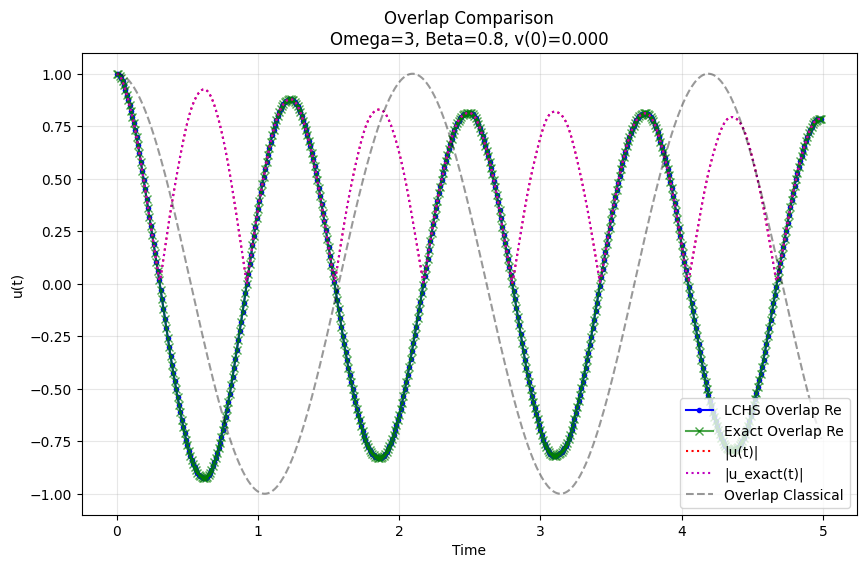

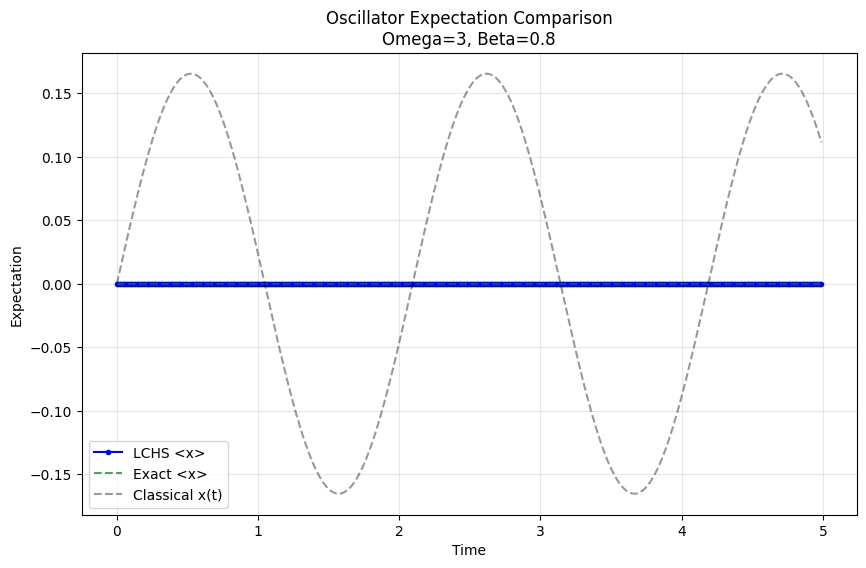

In [13]:
# --- 4. VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.plot(times, x_vals, 'b.-', label='LCHS Overlap Re', linewidth=1.5)
if PLOT_EXACT:
    plt.plot(times, u_exact_vals, 'gx-', label='Exact Overlap Re', alpha=0.7)
if PLOT_ABS:
    plt.plot(times, abs_vals, 'r:', label='|u(t)|')
    if PLOT_EXACT:
        plt.plot(times, abs_exact_vals, 'm:', label='|u_exact(t)|')
plt.plot(times, exact_solution, 'k--', label='Overlap Classical', alpha=0.4)
plt.title(f"Overlap Comparison\nOmega={omega}, Beta={beta}, v(0)={u_dot_0:.3f}")
plt.xlabel("Time")
plt.ylabel("u(t)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

if PLOT_OSC:
    plt.figure(figsize=(10, 6))
    plt.plot(times, x_exp_vals, 'b.-', label='LCHS <x>', linewidth=1.5)
    if PLOT_EXACT:
        plt.plot(times, x_exact_vals, 'g--', label='Exact <x>', alpha=0.7)
    plt.plot(times, x_classical, 'k--', label='Classical x(t)', alpha=0.4)
    if PLOT_P:
        plt.plot(times, p_exp_vals, 'r:', label='LCHS <p>')
    plt.title(f"Oscillator Expectation Comparison\nOmega={omega}, Beta={beta}")
    plt.xlabel("Time")
    plt.ylabel("Expectation")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
